# Train Isolation Forest for GPS-Derived Features

This notebook mirrors `tools/dt_ids/train_isolation_forest.py`.

If you upload the whole `data` folder into the Colab Files pane, this notebook will automatically use `/content/data`.

It loads the by-run split CSV files, excludes meta columns, trains a normal-only Isolation Forest, computes anomaly scores, and saves the model bundle.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: [dfs_ephemeral] Credentials propagation unsuccessful

In [ ]:
from pathlib import Path
import json
import os
import sys

import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest


In [ ]:
# Override this only if your split CSV files are not under /content/data/splits.
# Common values:
# DATA_ROOT_HINT = Path('/content/data')
# DATA_ROOT_HINT = Path('/content/drive/MyDrive/LAEA/data')
# DATA_ROOT_HINT = Path('/home/tim/laea/src/LAEA/data')
DEFAULT_HINTS = [
    Path('/content/data'),
    Path('/content/drive/MyDrive/LAEA/data'),
]
DATA_ROOT_HINT = next((path for path in DEFAULT_HINTS if path.exists()), None)

IGNORE_COLS = ["t", "mission_id", "split", "label"]
RANDOM_STATE = 42
N_ESTIMATORS = 200
MAX_SAMPLES = "auto"
CONTAMINATION = 0.01
THRESHOLD_QUANTILE = 0.99


def unique_paths(paths):
    seen = set()
    ordered = []
    for path in paths:
        if path is None:
            continue
        path = Path(path).expanduser()
        key = str(path)
        if key in seen:
            continue
        seen.add(key)
        ordered.append(path)
    return ordered


def candidate_data_roots():
    cwd = Path.cwd()
    roots = []

    if DATA_ROOT_HINT is not None:
        roots.append(Path(DATA_ROOT_HINT))

    env_data_root = os.environ.get("LAEA_DATA_ROOT")
    if env_data_root:
        roots.append(Path(env_data_root))

    env_repo_root = os.environ.get("LAEA_REPO_ROOT")
    if env_repo_root:
        roots.append(Path(env_repo_root) / "data")

    for base in [cwd, *cwd.parents]:
        roots.append(base / "data")

    roots.extend(
        [
            cwd,
            cwd / "data",
            cwd.parent / "data",
            Path("/content"),
            Path("/content/data"),
            Path("/content/drive/MyDrive"),
            Path("/content/drive/MyDrive/data"),
            Path("/data"),
        ]
    )
    return unique_paths(roots)


SEARCH_ROOTS = candidate_data_roots()

print("cwd:", Path.cwd())
print("python:", sys.executable)
print("data root hint:", DATA_ROOT_HINT if DATA_ROOT_HINT else '<auto-search>')
print("search roots:")
for root in SEARCH_ROOTS:
    status = "exists" if root.exists() else "missing"
    print(f"  - {root} [{status}]")


def find_split_file(filename):
    checked = []
    for root in SEARCH_ROOTS:
        candidate = root / "splits" / filename
        checked.append(candidate)
        if candidate.exists():
            return candidate.resolve()

    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        matches = sorted(root.rglob(filename))
        if matches:
            return matches[0].resolve()

    existing_split_dirs = [
        str((root / "splits").resolve())
        for root in SEARCH_ROOTS
        if (root / "splits").exists()
    ]
    checked_str = "\n".join(f"  - {path}" for path in checked)
    split_dir_str = (
        "\n".join(f"  - {path}" for path in existing_split_dirs)
        if existing_split_dirs
        else "  - none"
    )
    raise FileNotFoundError(
        f"Could not find {filename}.\n"
        f"Checked direct paths:\n{checked_str}\n"
        f"Existing split directories:\n{split_dir_str}\n\n"
        "If you uploaded the whole data folder into Colab Files, confirm that the CSVs are under /content/data/splits and rerun this cell.\n"
        "If your files are elsewhere, set DATA_ROOT_HINT to the folder that contains splits/.\n"
        "Example Colab upload path: DATA_ROOT_HINT = Path('/content/data')\n"
        "Example Colab Drive path: DATA_ROOT_HINT = Path('/content/drive/MyDrive/LAEA/data')\n"
        "Example local path: DATA_ROOT_HINT = Path('/home/tim/laea/src/LAEA/data')"
    )


TRAIN_PATH = find_split_file("normal_gps_features_train.csv")
VAL_PATH = find_split_file("normal_gps_features_val.csv")
TEST_PATH = find_split_file("normal_gps_features_test.csv")
DATA_ROOT = TRAIN_PATH.parent.parent
OUT_DIR = DATA_ROOT / "models/iforest_gps_v1_notebook"

OUT_DIR.mkdir(parents=True, exist_ok=True)
print("train path:", TRAIN_PATH)
print("val path:", VAL_PATH)
print("test path:", TEST_PATH)
print("output dir:", OUT_DIR)


cwd: /content
python: /usr/bin/python3
data root hint: <auto-search>
search roots:
  - /content/data [missing]
  - /data [missing]
  - /content [exists]
  - /content/drive/MyDrive [exists]
  - /content/drive/MyDrive/data [exists]
train path: /content/drive/MyDrive/data/splits/normal_gps_features_train.csv
val path: /content/drive/MyDrive/data/splits/normal_gps_features_val.csv
test path: /content/drive/MyDrive/data/splits/normal_gps_features_test.csv
output dir: /content/drive/MyDrive/data/models/iforest_gps_v1_notebook


In [ ]:
for path in (TRAIN_PATH, VAL_PATH, TEST_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Missing split CSV: {path.resolve()}")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train shape:", train_df.shape)
print("val shape:", val_df.shape)
print("test shape:", test_df.shape)
train_df.head()

train shape: (798139, 32)
val shape: (168643, 32)
test shape: (171601, 32)


,t,pos_x,pos_y,pos_z,vel_x,vel_y,vel_z,yaw,gps_lat,gps_lon,...,heading_gap,local_step_m,gps_step_m,step_gap,sat_change,sat_drop,fix_bad,dt,label,split
0,272.678,0.166990,0.026324,0.912216,0.466083,0.036174,-0.103817,0.205973,47.397742,8.545595,...,0.039770,0.015304,0.108629,0.093325,0.0,-0.0,1,0.050,0,train
1,272.728,0.198074,0.032780,0.906773,0.449585,0.022554,-0.116641,0.254742,47.397742,8.545595,...,0.009000,0.032210,0.000000,0.032210,0.0,-0.0,1,0.050,0,train
2,272.778,0.212264,0.035051,0.903626,0.439741,0.015799,-0.126622,0.282949,47.397742,8.545595,...,0.037206,0.014711,0.000000,0.014711,0.0,-0.0,1,0.050,0,train
3,272.829,0.241706,0.038936,0.896033,0.430880,0.000913,-0.137540,0.330186,47.397742,8.545595,...,0.084444,0.030653,0.000000,0.030653,0.0,-0.0,1,0.051,0,train
4,272.878,0.255525,0.040080,0.892168,0.434998,-0.005619,-0.139107,0.361068,47.397742,8.545595,...,0.115326,0.014395,0.000000,0.014395,0.0,-0.0,1,0.049,0,train


In [ ]:
feature_cols = [
    col
    for col in train_df.columns
    if col not in IGNORE_COLS and pd.api.types.is_numeric_dtype(train_df[col])
]

train_df = train_df.dropna(subset=feature_cols).reset_index(drop=True)
val_df = val_df.dropna(subset=feature_cols).reset_index(drop=True)
test_df = test_df.dropna(subset=feature_cols).reset_index(drop=True)

X_train = train_df[feature_cols].to_numpy()
X_val = val_df[feature_cols].to_numpy()
X_test = test_df[feature_cols].to_numpy()

print("num_features:", len(feature_cols))
feature_cols

num_features: 28


['pos_x',
 'pos_y',
 'pos_z',
 'vel_x',
 'vel_y',
 'vel_z',
 'yaw',
 'gps_lat',
 'gps_lon',
 'gps_alt',
 'gps_vx',
 'gps_vy',
 'gps_vz',
 'gps_fix',
 'gps_sat',
 'local_speed',
 'gps_speed',
 'speed_gap',
 'vertical_speed_gap',
 'gps_heading',
 'heading_gap',
 'local_step_m',
 'gps_step_m',
 'step_gap',
 'sat_change',
 'sat_drop',
 'fix_bad',
 'dt']

In [ ]:
model = IsolationForest(
    n_estimators=N_ESTIMATORS,
    max_samples=MAX_SAMPLES,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_train)

train_score = -model.decision_function(X_train)
val_score = -model.decision_function(X_val)
test_score = -model.decision_function(X_test)

threshold = float(np.quantile(train_score, THRESHOLD_QUANTILE))
threshold

-5.427607131504265e-17

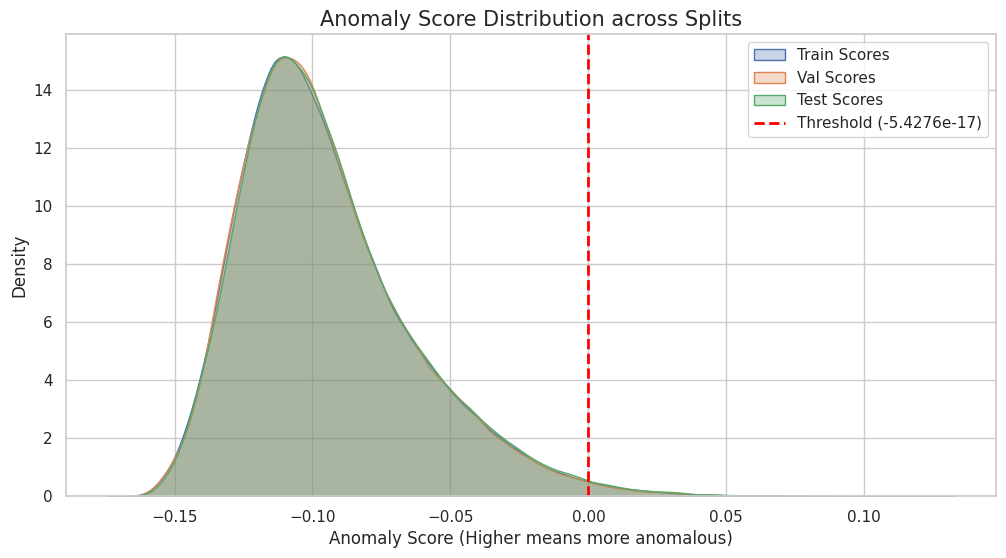

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 設定繪圖風格
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 繪製不同資料集的異常分數分佈
sns.kdeplot(train_score, label="Train Scores", fill=True, alpha=0.3)
sns.kdeplot(val_score, label="Val Scores", fill=True, alpha=0.3)
sns.kdeplot(test_score, label="Test Scores", fill=True, alpha=0.3)

# 畫出閾值線
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4e})')

plt.title("Anomaly Score Distribution across Splits", fontsize=15)
plt.xlabel("Anomaly Score (Higher means more anomalous)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.show()

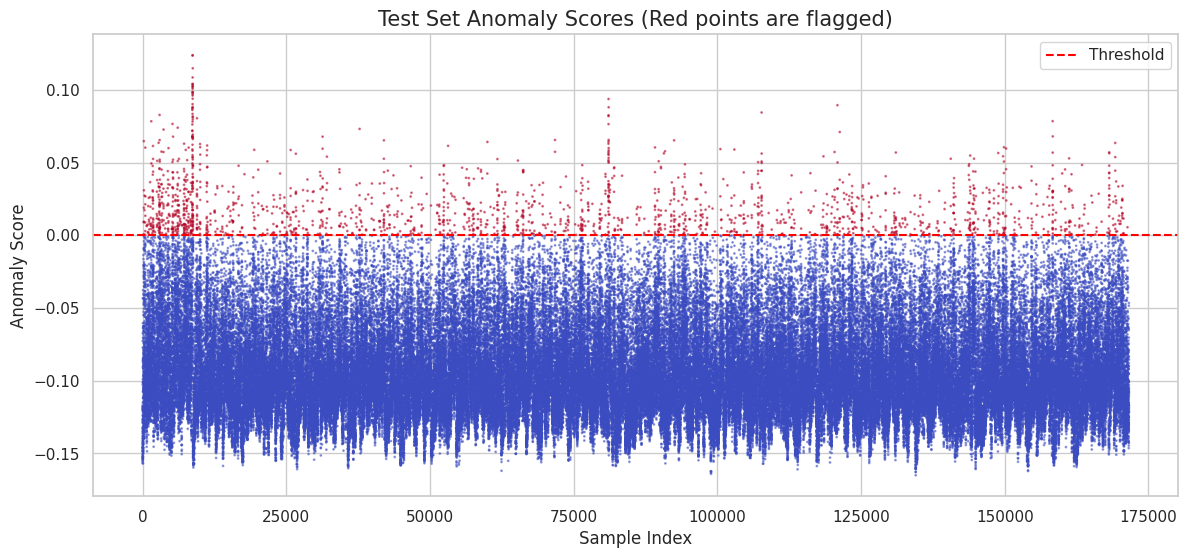

In [ ]:
# 針對測試集進行更詳細的視覺化，觀察分數與索引的關係
plt.figure(figsize=(14, 6))
plt.scatter(range(len(test_score)), test_score, c=(test_score >= threshold), cmap='coolwarm', s=1, alpha=0.5)
plt.axhline(y=threshold, color='red', linestyle='--', label='Threshold')
plt.title("Test Set Anomaly Scores (Red points are flagged)", fontsize=15)
plt.xlabel("Sample Index", fontsize=12)
plt.ylabel("Anomaly Score", fontsize=12)
plt.legend()
plt.show()

In [ ]:
def summarize_split(split_name, df, score, threshold):
    flagged = score >= threshold
    summary = {
        "split": split_name,
        "num_rows": int(len(df)),
        "num_flagged": int(flagged.sum()),
        "flagged_ratio": float(flagged.mean()) if len(df) else 0.0,
        "score_mean": float(np.mean(score)),
        "score_std": float(np.std(score)),
        "score_p95": float(np.quantile(score, 0.95)),
        "score_p99": float(np.quantile(score, 0.99)),
        "score_max": float(np.max(score)),
        "threshold": float(threshold),
    }
    if "mission_id" in df.columns:
        per_mission = (
            pd.DataFrame({"mission_id": df["mission_id"], "flagged": flagged.astype(int)})
            .groupby("mission_id", as_index=False)["flagged"]
            .mean()
            .rename(columns={"flagged": "flagged_ratio"})
        )
        summary["mission_flagged_ratio_mean"] = float(per_mission["flagged_ratio"].mean())
        summary["mission_flagged_ratio_max"] = float(per_mission["flagged_ratio"].max())
    return summary, flagged

train_summary, train_flagged = summarize_split("train", train_df, train_score, threshold)
val_summary, val_flagged = summarize_split("val", val_df, val_score, threshold)
test_summary, test_flagged = summarize_split("test", test_df, test_score, threshold)

summary_df = pd.DataFrame([train_summary, val_summary, test_summary])
summary_df

,split,num_rows,num_flagged,flagged_ratio,score_mean,score_std,score_p95,score_p99,score_max,threshold,mission_flagged_ratio_mean,mission_flagged_ratio_max
0,train,798139,7982,0.010001,-0.094888,0.031695,-0.034040,-5.427607e-17,0.119732,-5.427607e-17,0.010114,0.031946
1,val,168643,1574,0.009333,-0.094942,0.031413,-0.034725,-1.337348e-03,0.113085,-5.427607e-17,0.009472,0.026132
2,test,171601,1883,0.010973,-0.094164,0.031937,-0.032795,1.956399e-03,0.123800,-5.427607e-17,0.011070,0.046231


In [ ]:
model_bundle = {
    "model": model,
    "feature_columns": feature_cols,
    "ignore_columns": IGNORE_COLS,
    "threshold": threshold,
    "train_path": str(TRAIN_PATH.resolve()),
    "val_path": str(VAL_PATH.resolve()),
    "test_path": str(TEST_PATH.resolve()),
}

joblib.dump(model_bundle, OUT_DIR / "isolation_forest.joblib")
(OUT_DIR / "feature_columns.json").write_text(json.dumps(feature_cols, indent=2), encoding="utf-8")
(OUT_DIR / "training_config.json").write_text(
    json.dumps(
        {
            "ignore_cols": IGNORE_COLS,
            "random_state": RANDOM_STATE,
            "n_estimators": N_ESTIMATORS,
            "max_samples": MAX_SAMPLES,
            "contamination": CONTAMINATION,
            "threshold_quantile": THRESHOLD_QUANTILE,
            "threshold": threshold,
        },
        indent=2,
    ),
    encoding="utf-8",
)
summary_df.to_csv(OUT_DIR / "score_summary.csv", index=False)

train_scored = train_df.copy()
train_scored["anomaly_score"] = train_score
train_scored["is_flagged"] = train_flagged.astype(int)

val_scored = val_df.copy()
val_scored["anomaly_score"] = val_score
val_scored["is_flagged"] = val_flagged.astype(int)

test_scored = test_df.copy()
test_scored["anomaly_score"] = test_score
test_scored["is_flagged"] = test_flagged.astype(int)

train_scored.to_csv(OUT_DIR / "train_scored.csv", index=False)
val_scored.to_csv(OUT_DIR / "val_scored.csv", index=False)
test_scored.to_csv(OUT_DIR / "test_scored.csv", index=False)

summary_df

,split,num_rows,num_flagged,flagged_ratio,score_mean,score_std,score_p95,score_p99,score_max,threshold,mission_flagged_ratio_mean,mission_flagged_ratio_max
0,train,798139,7982,0.010001,-0.094888,0.031695,-0.034040,-5.427607e-17,0.119732,-5.427607e-17,0.010114,0.031946
1,val,168643,1574,0.009333,-0.094942,0.031413,-0.034725,-1.337348e-03,0.113085,-5.427607e-17,0.009472,0.026132
2,test,171601,1883,0.010973,-0.094164,0.031937,-0.032795,1.956399e-03,0.123800,-5.427607e-17,0.011070,0.046231


In [ ]:
test_scored.sort_values("anomaly_score", ascending=False).head(20)

,t,pos_x,pos_y,pos_z,vel_x,vel_y,vel_z,yaw,gps_lat,gps_lon,...,gps_step_m,step_gap,sat_change,sat_drop,fix_bad,dt,label,split,anomaly_score,is_flagged
8700,718.854,-18.390562,0.108441,-0.311667,-3.397827,-2.551948,-1.425898,-2.910584,47.397746,8.545357,...,0.911993,0.796225,0.0,-0.0,1,0.050,0,test,0.123800,1
8708,719.254,-19.723042,-0.452481,-0.845297,-3.343755,-1.087163,-1.697747,1.881811,47.397739,8.545340,...,1.544722,1.439828,0.0,-0.0,1,0.050,0,test,0.123634,1
8732,720.454,-21.295317,-0.298874,-0.564983,0.401988,0.977327,2.094336,1.112725,47.397739,8.545313,...,0.621552,0.520108,0.0,-0.0,1,0.050,0,test,0.114832,1
8705,719.104,-19.290735,-0.329736,-0.662346,-3.732555,-1.330643,-1.788446,2.274325,47.397746,8.545357,...,0.000000,0.272467,0.0,-0.0,1,0.048,0,test,0.108547,1
8703,719.005,-18.936792,-0.201126,-0.514828,-3.871038,-1.784874,-1.846262,2.675661,47.397746,8.545357,...,0.000000,0.276074,0.0,-0.0,1,0.051,0,test,0.104055,1
8709,719.309,-19.917492,-0.498667,-0.927107,-3.181298,-1.035723,-1.671034,1.718013,47.397739,8.545340,...,0.000000,0.215956,0.0,-0.0,1,0.055,0,test,0.103970,1
8713,719.507,-20.460367,-0.627745,-1.159548,-2.750565,-0.749792,-1.368090,1.589033,47.397739,8.545340,...,0.000000,0.197087,0.0,-0.0,1,0.052,0,test,0.102854,1
8715,719.604,-20.707550,-0.672683,-1.258266,-2.517934,-0.545518,-1.168546,1.595041,47.397739,8.545340,...,0.000000,0.180060,0.0,-0.0,1,0.050,0,test,0.102475,1
8707,719.204,-19.628366,-0.429787,-0.806252,-3.435182,-1.120771,-1.710581,1.934841,47.397746,8.545357,...,0.000000,0.255325,0.0,-0.0,1,0.050,0,test,0.101752,1
8701,718.904,-18.596237,-0.029038,-0.380407,-3.673207,-2.288788,-1.675108,3.104906,47.397746,8.545357,...,0.000000,0.256764,0.0,-0.0,1,0.050,0,test,0.100799,1
